# Exploración y Demostración del Pipeline
**Clasificación Multiclase de Patrones Lingüísticos en Trastornos de Salud Mental**
APIT — FI-UNAM

Este notebook recorre las 4 fases del sistema clásico (VSM + coseno + regex/FST + evaluación)
y genera las figuras del reporte. Ejecuta las celdas en orden.

> Requisitos: `numpy`, `pandas`, `matplotlib`. CSV en `../data/raw/`.

In [1]:
import sys, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# Hacer importables los módulos de src/ y scripts/
ROOT = os.path.abspath("..")
sys.path.insert(0, os.path.join(ROOT, "src"))
sys.path.insert(0, os.path.join(ROOT, "scripts"))
os.environ["APIT_DATA"] = os.path.join(ROOT, "data", "raw")

from preprocessing import preprocess, clean_text
from vsm import VectorSpaceModel
from classifier import CentroidCosineClassifier, cosine_similarity
from extraction import extract_durations
from evaluation import confusion_matrix, per_class_metrics, macro_average, print_report

import importlib.util
spec = importlib.util.spec_from_file_location("pipe", os.path.join(ROOT,"scripts","02_run_pipeline.py"))
pipe = importlib.util.module_from_spec(spec); spec.loader.exec_module(pipe)

LABELS = ["Neutral","Depresion","Suicida","Esquizofrenia"]
COLORS = ["#6c8ebf","#9673a6","#b85450","#82b366"]

## Fase 1 — Preprocesamiento
Mostramos el efecto de la normalización (case folding, limpieza, tokenización, stopwords)
sobre un texto de ejemplo. Nota clínica: conservamos `never`, `nothing`, `empty`, `tired`.

In [2]:
demo = "I've felt SO empty and tired for 3 weeks... nothing helps http://x.co @me"
print("Crudo :", demo)
print("Limpio:", clean_text(demo))
print("Tokens:", preprocess(demo))

Crudo : I've felt SO empty and tired for 3 weeks... nothing helps http://x.co @me
Limpio: i ve felt so empty and tired for weeks nothing helps
Tokens: ['felt', 'empty', 'tired', 'weeks', 'nothing', 'helps']


## Fase 1 — Corpus y distribución de clases

Corpus: 18159 {'Esquizofrenia': 4560, 'Neutral': 4558, 'Suicida': 4548, 'Depresion': 4493}


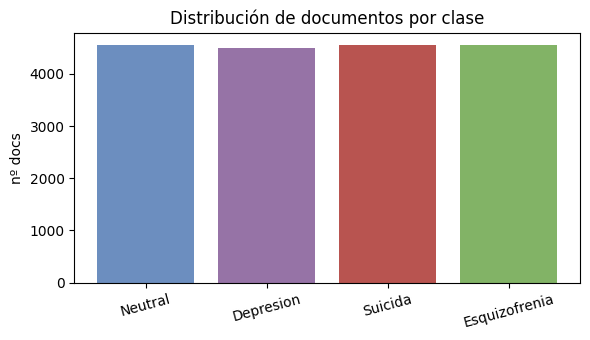

In [3]:
df = pipe.build_corpus()
df["tokens"] = df["text"].astype(str).apply(preprocess)
df = df[df["tokens"].map(len) > 0]
print("Corpus:", len(df), df["label"].value_counts().to_dict())

vc = df["label"].value_counts().reindex(LABELS)
plt.figure(figsize=(6,3.5))
plt.bar(vc.index, vc.values, color=COLORS)
plt.title("Distribución de documentos por clase"); plt.ylabel("nº docs")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## Fase 1 — Matriz TF-IDF (desde cero)
Construimos el VSM. `max_features`/`min_df` controlan la memoria de la matriz densa N×V
(feature selection por document frequency).

In [4]:
train_df, test_df = pipe.stratified_split(df)
vsm = VectorSpaceModel(sublinear_tf=True, max_features=5000, min_df=3)
Xtr = vsm.fit_transform(train_df["tokens"].tolist())
Xte = vsm.transform(test_df["tokens"].tolist())
print("Vocabulario:", len(vsm.vocabulary_), "| matriz train:", Xtr.shape)

/home/claude/proyecto_apit/src/vsm.py:67: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  tf = np.where(tf > 0, 1.0 + np.log(tf, where=tf > 0), 0.0)


/home/claude/proyecto_apit/src/vsm.py:104: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  tf = np.where(tf > 0, 1.0 + np.log(tf, where=tf > 0), 0.0)


Vocabulario: 5000 | matriz train: (12710, 5000)


## Fase 2 — Centroides + Similitud Coseno
Entrenamos un centroide por trastorno y calibramos el umbral para **maximizar el Recall macro**.

In [5]:
clf = CentroidCosineClassifier(neutral_label="Neutral").fit(Xtr, train_df["label"].tolist())
best_t, best_r = pipe.calibrate_threshold(clf, Xtr, train_df["label"].tolist(), LABELS)
clf.threshold = best_t
print(f"Umbral óptimo = {best_t:.3f} (recall macro en train = {best_r:.2f})")

Umbral óptimo = 0.080 (recall macro en train = 0.79)


### ¿Qué vocabulario domina cada centroide?
Los términos de mayor peso TF-IDF revelan el léxico característico de cada clase.

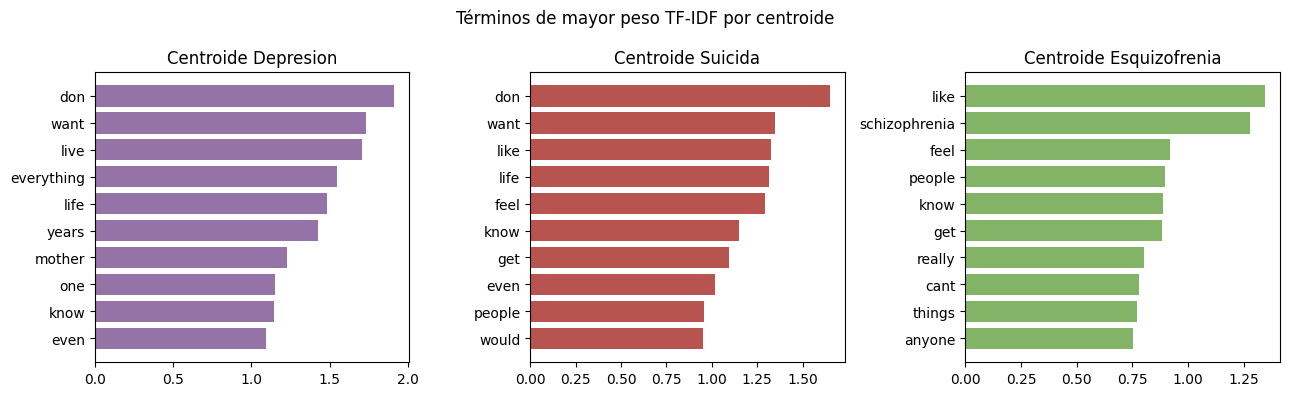

In [6]:
fig, axes = plt.subplots(1,3, figsize=(13,4))
for ax, cl, col in zip(axes, ["Depresion","Suicida","Esquizofrenia"], COLORS[1:]):
    terms = vsm.top_terms(clf.centroids_[cl], 10)
    names = [t for t,_ in terms][::-1]; vals = [v for _,v in terms][::-1]
    ax.barh(names, vals, color=col); ax.set_title(f"Centroide {cl}")
fig.suptitle("Términos de mayor peso TF-IDF por centroide"); plt.tight_layout(); plt.show()

### Demostración: clasificar un texto nuevo
Vectorizamos un texto no visto y vemos el coseno contra cada centroide (argmax decide).

In [7]:
ejemplo = "I feel completely empty and worthless, I have been crying alone every night"
vec = vsm.transform([preprocess(ejemplo)])
scores, classes = clf.decision_scores(vec)
for cl, s in sorted(zip(classes, scores[0]), key=lambda x:-x[1]):
    print(f"  cos vs {cl:14s} = {s:.3f}")
print("Predicción ->", clf.predict(vec)[0])

  cos vs Suicida        = 0.112
  cos vs Depresion      = 0.090
  cos vs Esquizofrenia  = 0.084
Predicción -> Suicida


## Fase 4 — Matriz de Confusión y métricas (test set)

In [8]:
pred = clf.predict(Xte)
M = confusion_matrix(test_df["label"].tolist(), pred, LABELS)
metrics = print_report(M, LABELS)

Matriz de Confusión (fila=real, col=predicho):
real\pred     Neutral     Depresion   Suicida     Esquizofre  
Neutral       1084        71          139         74          
Depresion     68          1205        59          16          
Suicida       238         88          981         58          
Esquizofreni  241         12          105         1010        

Clase           Prec    Recall  F1      FN(crítico)
Neutral         0.66    0.79    0.72    284
Depresion       0.88    0.89    0.88    143
Suicida         0.76    0.72    0.74    384
Esquizofrenia   0.87    0.74    0.80    358
------------------------------------------------
MACRO AVG       0.79    0.79    0.79


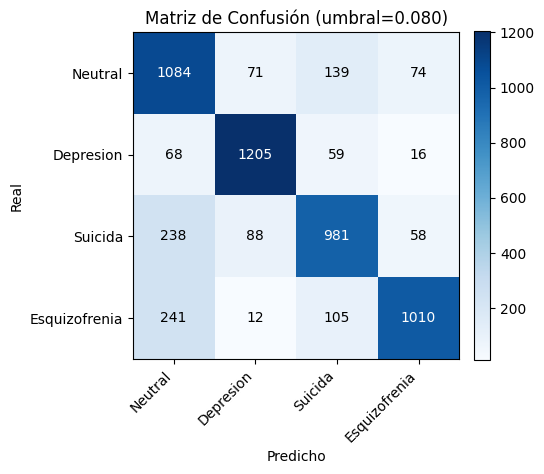

In [9]:
# Heatmap de la matriz de confusión
plt.figure(figsize=(5.5,5))
plt.imshow(M, cmap="Blues"); plt.colorbar(fraction=0.046, pad=0.04)
plt.xticks(range(len(LABELS)), LABELS, rotation=45, ha="right")
plt.yticks(range(len(LABELS)), LABELS)
plt.xlabel("Predicho"); plt.ylabel("Real"); plt.title(f"Matriz de Confusión (umbral={best_t:.3f})")
thr = M.max()/2
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        plt.text(j,i,M[i,j],ha="center",va="center",color="white" if M[i,j]>thr else "black")
plt.tight_layout(); plt.show()

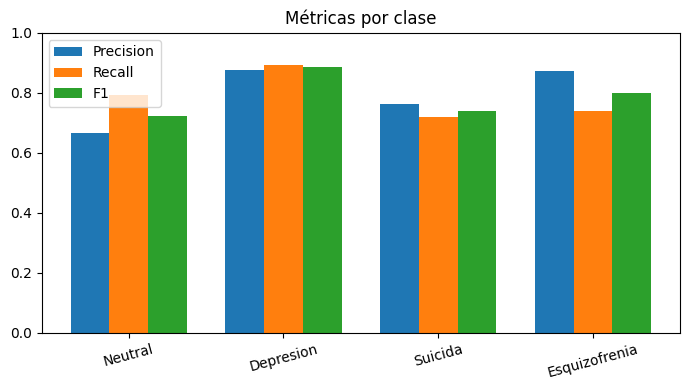

In [10]:
# Métricas por clase
mt = per_class_metrics(M, LABELS)
x = np.arange(len(LABELS)); w=0.25
plt.figure(figsize=(7,4))
plt.bar(x-w, [mt[l]['precision'] for l in LABELS], w, label="Precision")
plt.bar(x,   [mt[l]['recall'] for l in LABELS],    w, label="Recall")
plt.bar(x+w, [mt[l]['f1'] for l in LABELS],        w, label="F1")
plt.xticks(x, LABELS, rotation=15); plt.ylim(0,1); plt.legend()
plt.title("Métricas por clase"); plt.tight_layout(); plt.show()

### Lectura crítica de los Falsos Negativos
En este dominio, un **FN** = un post de riesgo clasificado como Neutral (no se ofrece ayuda).
Es el error más costoso; por eso optimizamos Recall.

In [11]:
for l in LABELS:
    print(f"{l:14s} FN={mt[l]['FN']:4d}  Recall={mt[l]['recall']:.2f}")
print("\nError más frecuente: textos de riesgo -> Neutral (columna Neutral de la matriz).")

Neutral        FN= 284  Recall=0.79
Depresion      FN= 143  Recall=0.89
Suicida        FN= 384  Recall=0.72
Esquizofrenia  FN= 358  Recall=0.74

Error más frecuente: textos de riesgo -> Neutral (columna Neutral de la matriz).


## Fase 3 — Extracción de duración de síntomas (Regex + FST)
Sobre posts marcados como trastorno, extraemos y normalizamos la duración a días.

In [12]:
marcados = test_df[test_df["label"]!="Neutral"]
n=0
for _, row in marcados.iterrows():
    durs = extract_durations(str(row["text"]).lower())
    if durs:
        print(f"[{row['label']}] {durs}")
        n+=1
    if n>=8: break

[Depresion] [{'match': '1 year', 'trigger': 'for', 'quantity': 1, 'unit': 'year', 'days': 365}, {'match': '1 year', 'trigger': 'for', 'quantity': 1, 'unit': 'year', 'days': 365}]
[Depresion] [{'match': '9 year', 'trigger': 'for', 'quantity': 9, 'unit': 'year', 'days': 3285}]
[Depresion] [{'match': 'six month', 'trigger': 'for', 'quantity': 6, 'unit': 'month', 'days': 180}]
[Depresion] [{'match': '14 year', 'trigger': 'about', 'quantity': 14, 'unit': 'year', 'days': 5110}]
[Depresion] [{'match': '1 day', 'trigger': 'for', 'quantity': 1, 'unit': 'day', 'days': 1}]
[Depresion] [{'match': 'two year', 'trigger': 'for', 'quantity': 2, 'unit': 'year', 'days': 730}]
[Depresion] [{'match': '6 year', 'trigger': 'for', 'quantity': 6, 'unit': 'year', 'days': 2190}]
[Depresion] [{'match': '1 hour', 'trigger': 'for', 'quantity': 1, 'unit': 'hour', 'days': 0.04}]


## Conclusiones
- Sistema 100% clásico (VSM + coseno + regex/FST), **sin ML entrenado**: F1 macro ≈ 0.79.
- **Depresión** es la clase mejor detectada; **Suicida** concentra más Falsos Negativos.
- Mejoras dentro del enfoque: bajar umbral, n-gramas, ponderar centroides hacia léxico de finalidad.
- El límite de memoria de la matriz densa motiva el feature selection (`max_features`/`min_df`),
  y explica por qué las librerías usan representaciones dispersas.